# Anexo - TFM MPAD de Marcé_Blaya_Marc

Este documento anexo recoge de forma detallada toda la información relacionada con el proyecto, incluyendo el proceso de **extracción y procesamiento de datos**, así como la **creación del campograma y la gestión de logos**.

Además, se describe la **estructura de directorios del proyecto**, facilitando la comprensión de su organización interna, y se incluye un **breve tutorial** que explica cómo trasladar y desplegar el código desde un entorno local (PC) a **Streamlit**.

<br>

## 0. Preparación del Entorno de Trabajo  

In [ ]:
# pnadas -> Manipulación y análisis de datos
import pandas as pd             

# time -> Medición de tiempo de ejecución y manejo de fechas
import time      

# os -> Interacción con el sistema operativo (rutas, archivos, etc.)
import os                

# tqdm -> Barra de progreso para loops y operaciones iterativas
from tqdm.notebook import tqdm 

# logging -> Registro de eventos, errores y mensajes de depuración
import logging

# sys -> Manipulación de rutas y entorno de ejecución
import sys

# inspect -> Inspección de funciones/objetos en runtime
import inspect

# sqlite3 -> Interacción con bases de datos SQLite
import sqlite3

# mplsoccer -> Visualización de datos de fútbol (estadísticas, mapas de calor, etc.)
from mplsoccer import Pitch, VerticalPitch

# PIL -> Manipulación de imágenes (abrir, dibujar y aplicar fuentes)
from PIL import Image, ImageDraw, ImageFont  

# numpy -> Operaciones numéricas y manejo de arrays
import numpy as np

# rapidfuzz -> Búsqueda difusa y comparación de cadenas de texto
from rapidfuzz import process

# unicodedate -> Normalización de caracteres Unicode (eliminar acentos, caracteres especiales, etc.)
import unicodedata

<br>

## 1. Recopilación y Preparación de Datos

Para comenzar con la creación de una **aplicación web mediante Streamlit**, es imprescindible contar previamente con un **conjunto de datos sólido** sobre el que trabajar. En este caso, el proceso se inicia mediante la obtención de un **dataset inicial procedente de Fbref a través de LanusStats**, lo que proporciona una **base mínima funcional** para desarrollar las primeras características de la aplicación.

Una vez disponible este primer conjunto de datos, el siguiente paso consiste en la **revisión por parte del administrador de las solicitudes o mensajes enviados por los usuarios**. Este proceso permite identificar **qué competiciones son más demandadas**, con el objetivo de **priorizar su inclusión en la base de datos** y orientar el crecimiento del sistema de forma eficiente.

Esta decisión responde a una **medida de control, seguridad y sostenibilidad del sistema**. Dado que se trabaja con un **proveedor de datos en abierto**, resulta **éticamente y técnicamente problemático** permitir que los usuarios puedan forzar **instalaciones masivas o peticiones continuas sin control**, lo que podría comprometer tanto el servicio como la fuente de datos.

A lo largo de esta sección se detalla el proceso completo de **extracción, procesamiento e importación de los datos**, hasta la construcción de la **base final sobre la que se desarrollará la aplicación**.

<br>

### <h3> LanusStats: Librería de Scraping </h3>

<h4 style="margin-top:20px;"> ¿Qué es LanusStats? </h4>

<div style="display: flex; align-items: center;"> 
  <img src="../assets/img/lanustats_logo.jpg" width="120" style="float: left; margin-right: 20px;">
  <div>

Es una librería o proyecto disponible en **GitHub**, orientado al **web scraping y análisis de estadísticas de fútbol**. Su objetivo principal es **extraer información detallada de jugadores, equipos, partidos y transferencias** desde diferentes fuentes web como FBref, Transfermarkt, FotMob o SofaScore, y convertirla en estructuras de datos que puedan ser analizadas o almacenadas en bases de datos.

Esta herramienta permite realizar **seguimiento de rendimiento, comparaciones entre jugadores y equipos, análisis de tendencias de mercado**, así como generar **visualizaciones e informes deportivos** de manera más eficiente y precisa.

<h4 style="margin-top:20px;"> ¿Cómo se instala? </h4>

Para instalar y utilizar **LanusStats**, lo primero es asegurarse de que la librería se encuentra disponible en el entorno de trabajo. Para ello, se puede ejecutar `pip show LanusStats`, lo que permite verificar si ya está instalada y evitar realizar una instalación innecesaria con `pip install`. 

En caso de que no esté presente o se desee actualizar a la última versión, se procede a instalarla (`pip install`) o actualizarla (`pip install --upgrade`). Una vez confirmada la instalación, se importa la librería y se inicializa la clase correspondiente, como la clase `Fbref`, que ofrece acceso a los métodos de **scraping de estadísticas de fútbol**. De esta manera, la librería queda lista para **extraer, procesar y analizar datos deportivos** de forma eficiente, facilitando el manejo de información sobre jugadores, equipos y partidos desde distintas fuentes web.

In [ ]:
# Mostrar información sobre un paquete instalado en el entorno 
%pip show LanusStats

Name: lanusstats
Version: 2.0.1
Summary: Python library for scraping football data and visualize it / Libreria de Python para scrapear data de fútbol y visualizarla
Home-page: https://github.com/federicorabanos
Author: Federico Rábanos
Author-email: lanusstats@gmail.com
License: MIT
Location: c:\Users\marc_\AppData\Local\Programs\Python\Python313\Lib\site-packages
Requires: bs4, faker, matplotlib, mplsoccer, numpy, pandas, Pillow, pydoll-python, requests, setuptools, undetected-chromedriver
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Importar la librería LanusStats y asignarle el alias 'ls'
import LanusStats as ls  

# Inicializar la clase Fbref de LanusStats para poder usar sus métodos de scraping de estadísticas
fbref = ls.Fbref()

<h4 style="margin-top:20px;"> ¿Cómo resolver el problema? </h4>

El motivo por el que el **código con LanusStats dejó de funcionar** se debe a un **cambio en la librería**. Anteriormente, se usaba una **versión antigua de LanusStats** que podía scrapear las estadísticas de FBref utilizando solo el entorno local de Windows con **Python** y librerías habituales como **requests** y **BeautifulSoup**.

En la versión más reciente, LanusStats incorpora internamente un **módulo llamado pydoll** para manejar Chrome de manera automatizada en algunas funciones de FBref. El problema es que **pydoll nunca fue publicado en PyPI** ni se incluye como dependencia instalable. Por ello, al intentar importar LanusStats en tu PC, Python no puede encontrar el módulo y aparece el error:`ModuleNotFoundError: No module named 'pydoll'`.

En otras palabras, la **librería cambió**, pero tu entorno local no tiene la dependencia que ahora intenta usar. Por eso antes todo funcionaba correctamente y ahora no. Tampoco sirve **actualizar pip o reinstalar LanusStats**, porque la dependencia simplemente **no existe para instalar** en tu máquina.

Para seguir usando LanusStats en tu PC, se pueden considerar tres opciones:

1. Aplicar un **parche** que elimine la dependencia de pydoll.
2. Usar un **entorno como Google Colab**, donde la librería funciona sin problemas.
3. Volver a una **versión anterior** de LanusStats que no tuviera este problema.

In [ ]:
# Forzar la reinstalación del paquete 'LanusStats' 
%pip install --force-reinstall "LanusStats<1.9.0"

Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following yanked versions: 1.0.0, 1.0.1, 1.0.2, 1.1.0, 1.2.0, 1.3.1, 1.5.0, 1.5.1, 1.5.2, 1.5.3, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.7.3, 1.7.6, 1.8.0, 1.8.1, 1.8.2, 1.8.3, 1.8.4, 1.8.5, 1.8.6, 1.8.7, 1.9.0, 1.9.1, 2.0.0
ERROR: Could not find a version that satisfies the requirement LanusStats<1.9.0 (from versions: 2.0.1)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for LanusStats<1.9.0


Al ejecutar `%pip install --force-reinstall "LanusStats<1.9.0"` observamos que **pip devuelve un error** indicando que no puede encontrar ninguna versión que cumpla con el requisito, y además **lista todas las versiones anteriores como “yanked”**.

Esto significa que **todas las versiones de LanusStats anteriores a la 1.9.0** han sido marcadas en **PyPI como no recomendadas para instalar**. Aunque estas versiones todavía existen en el repositorio, el autor o PyPI las ha señalado como **obsoletas, inestables o con posibles errores**, por lo que **pip las ignora automáticamente**.

En consecuencia, **solo queda disponible la versión 1.9.0**, que es la versión más reciente. Sin embargo, en tu **entorno local**, esta versión puede generar el **error por la dependencia inexistente `pydoll`**, impidiendo que la librería funcione correctamente.

In [ ]:
# Se especifica la versión exacta 1.8.7 para garantizar que esa versión específica se instale
%pip install --force-reinstall LanusStats==1.8.7

  Using cached lanusstats-1.8.7-py3-none-any.whl.metadata (14 kB)
  Using cached mplsoccer-1.6.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached bs4-0.0.2-py2.py3-none-any.whl.metadata (411 bytes)
  Using cached undetected_chromedriver-3.5.5-py3-none-any.whl
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached trio_websocket-0.12.2-py3-none-any.

Reason for being yanked: <none given>
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pydoll-python 2.20.2 requires websockets<15,>=14, but you have websockets 16.0 which is incompatible.
pyppeteer 2.0.0 requires urllib3<2.0.0,>=1.25.8, but you have urllib3 2.6.3 which is incompatible.
pyppeteer 2.0.0 requires websockets<11.0,>=10.0, but you have websockets 16.0 which is incompatible.
rich 9.13.0 requires typing-extensions<4.0.0,>=3.7.4, but you have typing-extensions 4.15.0 which is incompatible.


In [ ]:
# Validar la información sobre un paquete instalado en el entorno 
%pip show LanusStats

Name: lanusstats
Version: 1.8.7
Summary: Python library for scraping football data and visualize it / Libreria de Python para scrapear data de fútbol y visualizarla
Home-page: https://github.com/federicorabanos
Author: Federico Rábanos
Author-email: lanusstats@gmail.com
License: MIT
Location: c:\Users\marc_\AppData\Local\Programs\Python\Python313\Lib\site-packages
Requires: bs4, faker, matplotlib, mplsoccer, numpy, pandas, Pillow, requests, undetected-chromedriver
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Importar la librería LanusStats y asignarle el alias 'ls'
import LanusStats as ls  

# Inicializar la clase Fbref de LanusStats para poder usar sus métodos de scraping de estadísticas
fbref = ls.Fbref()

<h4 style="margin-top:20px;"> ¿Qué información nos permite obtener LanusStats de Fbref? </h4>

<div style="display: flex; align-items: center;"> 
  <img src="../assets/img/fbref logo.png" width="120" style="float: left; margin-right: 20px;">
  <div>

En el caso específico de **Fbref**, LanusStats permite acceder a estadísticas detalladas de jugadores y equipos en distintas competiciones y temporadas. Entre la información que se puede obtener se incluyen:

* Estadísticas de **partidos jugados, goles, asistencias, tarjetas y minutos disputados**.
* Datos de **posesión, tiros, pases, duelos, regates y rendimiento defensivo**.
* Comparaciones entre jugadores dentro de un equipo o entre distintos equipos.
* Información histórica para analizar **evolución de rendimiento a lo largo de una temporada** o entre temporadas.

En resumen, LanusStats con Fbref facilita la **obtención de datos completos y confiables** para análisis detallados del rendimiento deportivo.

<br>

### <h3> Conjunto de Datos de Jugadores Europeos </h3>

Mediante la función **`get_possible_leagues`** de **LanusStats** se obtienen los nombres de todas las competiciones disponibles. Esta información permite **crear un diccionario** con los nombres de las competiciones de las cuales se desea obtener las estadísticas de los jugadores, facilitando así la selección y organización de los datos para su posterior análisis.

In [ ]:
# Obtener el listado de Competiciones disponibles
from LanusStats.functions import get_possible_leagues

# Los argumentos de ejemplo no importan; solo queremos el diccionario completo.
ligas = get_possible_leagues('Copa de la Liga', '2023', 'Fbref')

# El diccionario tiene varias fuentes: 'FBref', 'Fotmob', 'SofaScore', etc.
# Para ver solo FBref:
ligas_fbref = ligas['Fbref']

# Listar todas las competiciones (claves) disponibles para FBref
print("Competiciones disponibles en FBref:")
for nombre in ligas_fbref.keys():
    print("-", nombre)

Competiciones disponibles en FBref:
- Copa de la Liga
- Primera Division Argentina
- Primera Division Uruguay
- Brasileirao
- Brasileirao B
- Primera Division Colombia
- Primera Division Chile
- Primera Division Peru
- Primera Division Venezuela
- Primera Division Ecuador
- Primera Division Bolivia
- Primera Division Paraguay
- Brasileirao F
- MLS
- USL Championship
- Premier League
- La Liga
- Ligue 1
- Bundesliga
- Serie A
- Big 5 European Leagues
- Danish Superliga
- Eredivise
- Primeira Liga Portugal
- Copa America
- Euros
- Saudi League
- EFL Championship
- La Liga 2
- Belgian Pro League
- Challenger Pro League
- 2. Bundesliga
- Ligue 2
- Serie B
- J1 League
- NSWL
- Wowens Super League
- Liga F
- Premier Division South Africa
- Champions League
- Europa League
- Conference League
- Copa Libertadores
- Liga MX


Las competiciones seleccionadas para la extracción de datos incluyen tanto la Primera División como la Segunda División de España y Francia. Para facilitar este proceso, se creó un **listado de ligas** que contiene sus respectivos **nombres y códigos abreviados**, lo que permite **identificar y organizar de manera sencilla los datos** obtenidos de cada competición. De esta manera, se asegura que la información de cada liga se gestione de forma clara y estructurada. 

Las **ligas incluidas** son: **Premier League, La Liga, Ligue 1, Bundesliga, Serie A, EFL Championship, La Liga 2, Ligue 2, 2. Bundesliga y Serie B**.

In [ ]:
# Crear diccionario con el nombre de las competiciones
leagues_dict = {
    "Premier League": "PL",
    "La Liga": "LL",
    "Ligue 1": "L1",
    "Bundesliga": "BL",
    "Serie A": "SA",
    "EFL Championship": "CH",
    "La Liga 2": "LL2",
    "Ligue 2": "L2",
    "2. Bundesliga": "2B",
    "Serie B": "SB" 
}

Con las **competiciones seleccionadas**, se crea una **estructura de almacenamiento** para **guardar todos los DataFrames**. Se recorre cada **liga** incluida en el **listado previamente definido** y, mediante la función **`get_all_player_season_stats`** de **Fbref**, se **extraen las estadísticas de todos los jugadores** para la **temporada 2024-2025**. Una vez obtenemos cada **DataFrame** se asigna a su **liga correspondiente** dentro de esta **estructura**

El proceso incluye un **mecanismo de manejo de errores** para **capturar posibles fallos** durante la extracción, así como una **pausa de 5 segundos** entre la **obtención de datos de cada liga**, garantizando un **scraping más estable** y evitando **sobrecargar los servidores**.

In [ ]:
# Diccionario donde almacenar resultados
dfs_leagues = {}

# Barra de progreso global
with tqdm(total=len(leagues_dict), desc="Extrayendo ligas", unit="liga") as pbar:
    for league_name in leagues_dict.keys():
        # Mostrar nombre de liga actual en la barra
        pbar.set_description(f"Extrayendo {league_name}")

        try:
            # Aquí tu función de extracción
            data = fbref.get_all_player_season_stats(league_name, season='2024-2025', save_csv=False)

            # Guardar el resultado en el diccionario (aunque no sea DataFrame)
            dfs_leagues[league_name] = data

            # Mensaje de éxito
            msg = f"✅ Información de {league_name} extraída con éxito"

        except Exception as e:
            # Mensaje de error
            msg = f"❌ Error en {league_name}: {e}"

        # Actualizar barra con mensaje
        pbar.set_postfix_str(msg)
        pbar.update(1)
        pbar.refresh()

        # Espera opcional entre ligas
        time.sleep(5)

# Mensaje final
print("\n✅ Extracción completada para todas las ligas.")
print(f"📊 Ligas con información extraída: {list(dfs_leagues.keys())}")

Extrayendo ligas:   0%|          | 0/10 [00:00<?, ?liga/s]

stats
Starting to scrape player data from Fbref...
keepers
Starting to scrape player data from Fbref...
keepersadv
Starting to scrape player data from Fbref...
shooting
Starting to scrape player data from Fbref...
passing
Starting to scrape player data from Fbref...
passing_types
Starting to scrape player data from Fbref...
gca
Starting to scrape player data from Fbref...
defense
Starting to scrape player data from Fbref...
possession
Starting to scrape player data from Fbref...
playingtime
Starting to scrape player data from Fbref...
misc
Starting to scrape player data from Fbref...
stats
Starting to scrape player data from Fbref...
keepers
Starting to scrape player data from Fbref...
keepersadv
Starting to scrape player data from Fbref...
shooting
Starting to scrape player data from Fbref...
passing
Starting to scrape player data from Fbref...
passing_types
Starting to scrape player data from Fbref...
gca
Starting to scrape player data from Fbref...
defense
Starting to scrape player 

Para **inspeccionar la información extraída**, se **itera sobre cada liga** en el **diccionario** y se **muestra algunas filas de cada DataFrame**. Esto permite **ver de manera rápida la estructura de los datos**, incluyendo las **columnas disponibles** y algunos **valores de ejemplo** de los **jugadores de cada liga**.

De esta forma, se puede **verificar** que cada **liga contiene correctamente** sus respectivos **DataFrames** con las **estadísticas individuales de los jugadores** antes de proceder a **unificarlos o analizarlos**.

In [ ]:
# Iterar sobre cada liga y mostrar la primera fila
for league_name, df in dfs_leagues.items():
    print(f"\n\n📄 Primera fila de {league_name}:\n")
    print(df)  



📄 Primera fila de Premier League:

(                  Player stats_Nation stats_Pos     stats_Squad      stats_Comp stats_Age stats_Born stats_MP stats_Starts stats_Min stats_90s stats_Gls stats_Ast stats_G+A stats_G-PK stats_PK  \
0             Max Aarons      eng ENG        DF     Bournemouth  Premier League        24       2000        3            1        86       1.0         0         0         0          0        0   
1      Joshua Acheampong      eng ENG        DF         Chelsea  Premier League        18       2006        4            2       170       1.9         0         0         0          0        0   
2            Tyler Adams       us USA        MF     Bournemouth  Premier League        25       1999       28           21     1,965      21.8         0         3         3          0        0   
3       Tosin Adarabioyo      eng ENG        DF         Chelsea  Premier League        26       1997       22           15     1,409      15.7         1         1         2      

<br>

### <h3> Integración de Conjuntos de Datos </h3>

**Obtenidas las stats de los jugadores de cada liga** y **almacenados en el diccionario**, el siguiente paso consiste en **unificar toda la información en un único DataFrame general**. Esto permitirá disponer de una **estructura de datos consolidada** con las **estadísticas de jugadores** de todas las **competiciones seleccionadas**.

Para ello, se **combinarán los distintos DataFrames** almacenados en el diccionario (**`dfs_leagues`**), generando un **único DataFrame principal** que contendrá los **datos completos**. Además, se **añadirá una columna identificadora** con el **nombre de la liga de origen**, de modo que los **registros puedan diferenciarse fácilmente** dentro del conjunto total.

Esta **integración** facilitará el **análisis comparativo entre ligas**, la **búsqueda de jugadores específicos** y la **aplicación de procesos de limpieza o transformación** de forma **unificada**, antes de su **almacenamiento o visualización final**.

In [ ]:
# Función para unificar varios DataFrames de ligas en uno solo
def unify_leagues(dfs_leagues: dict, leagues_dict: dict) -> pd.DataFrame:

    # Función auxiliar para detectar y resolver columnas duplicadas
    def resolve_duplicate_columns(df: pd.DataFrame) -> pd.DataFrame:
        
        # Crear una copia del DataFrame original
        df = df.copy()
        # Convertir las columnas a una serie para detectar duplicados
        cols = pd.Series(df.columns)

        # Iterar sobre cada columna duplicada encontrada
        for dup in cols[cols.duplicated()].unique():
            # Obtener los índices donde aparece la columna duplicada
            dup_indices = cols[cols == dup].index.tolist()
            # Seleccionar las columnas duplicadas para comparar
            duplicate_dfs = df.iloc[:, dup_indices]

            # Comprobar si todas las columnas duplicadas son idénticas
            if (duplicate_dfs.nunique(axis=1) <= 1).all():
                # Eliminar las duplicadas si son iguales
                df = df.drop(df.columns[dup_indices[1:]], axis=1)
                cols = pd.Series(df.columns)
            else:
                # Si difieren, renombrar las duplicadas con sufijo numérico
                for i, idx in enumerate(dup_indices):
                    if i == 0:
                        continue
                    df.columns.values[idx] = f"{dup}_{i}"

        # Devolver el DataFrame con nombres de columnas únicos
        return df

    # Extraer DataFrames cuando los valores vienen en tuplas
    for league_name, value in dfs_leagues.items():
        if isinstance(value, tuple):
            dfs_leagues[league_name] = value[0]

    # Filtrar DataFrames válidos (no vacíos ni None)
    valid_dfs = {league: df for league, df in dfs_leagues.items() if df is not None and not df.empty}
    if not valid_dfs:
        print("❌ No hay DataFrames válidos para unir.")
        return pd.DataFrame()

    # Inicializar listas para almacenar resultados
    unified_dfs = []
    all_columns = []

    # Procesar cada DataFrame de liga
    for league_name, df in valid_dfs.items():
        # Crear copia del DataFrame original
        df = df.copy()

        # Resolver columnas duplicadas
        df = resolve_duplicate_columns(df)

        # Agregar columna 'league' con el código de liga correspondiente
        league_code = leagues_dict.get(league_name, league_name)
        df["league"] = league_code

        # Registrar las columnas encontradas
        all_columns.extend([c for c in df.columns if c not in all_columns])

        # Agregar el DataFrame procesado a la lista
        unified_dfs.append(df)

    # Reordenar columnas (todas + 'league' al final)
    final_cols = [c for c in all_columns if c != "league"] + ["league"]

    # Concatenar todos los DataFrames en uno solo
    df_general = pd.concat([df.reindex(columns=final_cols) for df in unified_dfs], ignore_index=True)
        
    # Mostrar las dimensiones totales del DataFrame unificado (filas, columnas)
    print(f"\n📏 Dimensiones generales del DataFrame: {df_general.shape}")

    # Mostrar la cantidad total de registros (jugadores)
    print(f"\n📊 Total de jugadores: {len(df_general)}\n")

    # Validar que existan las columnas necesarias para el conteo
    required_cols = ["Player", "league", "stats_Comp"]   # Columnas requeridas
    missing_cols = [col for col in required_cols if col not in df_general.columns]  # Detectar ausentes
    
    # Mostrar advertencia si faltan columnas
    if missing_cols:
        print(f"⚠️ No se pueden contar jugadores: faltan columnas {missing_cols}")
    else:
        # Mostrar conteo de jugadores por liga
        print("🏆 Conteo de jugadores por liga:\n")
        
        # Agrupar el DataFrame por la columna descriptiva de liga ('stats_Comp')
        for league_name, group in df_general.groupby("stats_Comp"):
            # Contar jugadores únicos en cada liga
            total_players = group["Player"].nunique()
            
            # Obtener el código de liga correspondiente (si existe)
            league_code = group["league"].iloc[0] if "league" in group.columns else "N/A"
            
            # Mostrar el resultado formateado
            print(f"👤 {league_name} ({league_code}): {total_players} jugadores")

    # Mostrar una vista previa del DataFrame unificado
    print("\n🔍 Vista previa del DataFrame combinado:")
    display(df_general.head())
    
    # Devolver el DataFrame final unificado
    return df_general

In [ ]:
# Unificar los DataFrames de las diferentes ligas en uno solo
dataset_stats_players_fbref = unify_leagues(dfs_leagues, leagues_dict)


📏 Dimensiones generales del DataFrame: (5988, 239)

📊 Total de jugadores: 5988

🏆 Conteo de jugadores por liga:

👤 2. Bundesliga (2B): 522 jugadores
👤 Bundesliga (BL): 481 jugadores
👤 EFL Championship (CH): 736 jugadores
👤 La Liga (LL): 588 jugadores
👤 La Liga 2 (LL2): 658 jugadores
👤 Ligue 1 (L1): 542 jugadores
👤 Ligue 2 (L2): 519 jugadores
👤 Premier League (PL): 562 jugadores
👤 Serie A (SA): 599 jugadores
👤 Serie B (SB): 588 jugadores

🔍 Vista previa del DataFrame combinado:


,Player,stats_Nation,stats_Pos,stats_Squad,stats_Comp,stats_Age,stats_Born,stats_MP,stats_Starts,stats_Min,stats_90s,stats_Gls,stats_Ast,stats_G+A,stats_G-PK,stats_PK,stats_PKatt,stats_CrdY,stats_CrdR,stats_xG,stats_npxG,stats_xAG,stats_npxG+xAG,stats_PrgC,stats_PrgP,stats_PrgR,stats_Gls_1,stats_Ast_1,stats_G+A_1,stats_G-PK_1,stats_G+A-PK,stats_xG_1,stats_xAG_1,stats_xG+xAG,stats_npxG_1,stats_npxG+xAG_1,shooting_Nation,shooting_Pos,shooting_Squad,shooting_Comp,shooting_Age,shooting_Born,shooting_90s,shooting_Gls,shooting_Sh,shooting_SoT,shooting_SoT%,shooting_Sh/90,shooting_SoT/90,shooting_G/Sh,shooting_G/SoT,shooting_Dist,shooting_FK,shooting_PK,shooting_PKatt,shooting_xG,shooting_npxG,shooting_npxG/Sh,shooting_G-xG,shooting_np:G-xG,passing_Nation,passing_Pos,passing_Squad,passing_Comp,passing_Age,passing_Born,passing_90s,passing_Cmp,passing_Att,passing_Cmp%,passing_TotDist,passing_PrgDist,passing_Cmp_1,passing_Att_1,passing_Cmp%_1,passing_Cmp_2,passing_Att_2,passing_Cmp%_2,passing_Cmp_3,passing_Att_3,passing_Cmp%_3,passing_Ast,passing_xAG,passing_xA,passing_A-xAG,passing_KP,passing_1/3,passing_PPA,passing_CrsPA,passing_PrgP,passing_types_Nation,passing_types_Pos,passing_types_Squad,passing_types_Comp,passing_types_Age,passing_types_Born,passing_types_90s,passing_types_Att,passing_types_Live,passing_types_Dead,passing_types_FK,passing_types_TB,passing_types_Sw,passing_types_Crs,passing_types_TI,passing_types_CK,passing_types_In,passing_types_Out,passing_types_Str,passing_types_Cmp,passing_types_Off,passing_types_Blocks,gca_Nation,gca_Pos,gca_Squad,gca_Comp,gca_Age,gca_Born,gca_90s,gca_SCA,gca_SCA90,gca_PassLive,gca_PassDead,gca_TO,gca_Sh,gca_Fld,gca_Def,gca_GCA,gca_GCA90,gca_PassLive_1,gca_PassDead_1,gca_TO_1,gca_Sh_1,gca_Fld_1,gca_Def_1,defense_Nation,defense_Pos,defense_Squad,defense_Comp,defense_Age,defense_Born,defense_90s,defense_Tkl,defense_TklW,defense_Def 3rd,defense_Mid 3rd,defense_Att 3rd,defense_Tkl_1,defense_Att,defense_Tkl%,defense_Lost,defense_Blocks,defense_Sh,defense_Pass,defense_Int,defense_Tkl+Int,defense_Clr,defense_Err,possession_Nation,possession_Pos,possession_Squad,possession_Comp,possession_Age,possession_Born,possession_90s,possession_Touches,possession_Def Pen,possession_Def 3rd,possession_Mid 3rd,possession_Att 3rd,possession_Att Pen,possession_Live,possession_Att,possession_Succ,possession_Succ%,possession_Tkld,possession_Tkld%,possession_Carries,possession_TotDist,possession_PrgDist,possession_PrgC,possession_1/3,possession_CPA,possession_Mis,possession_Dis,possession_Rec,possession_PrgR,playingtime_Nation,playingtime_Pos,playingtime_Squad,playingtime_Comp,playingtime_Age,playingtime_Born,playingtime_MP,playingtime_Min,playingtime_Mn/MP,playingtime_Min%,playingtime_90s,playingtime_Starts,playingtime_Mn/Start,playingtime_Compl,playingtime_Subs,playingtime_Mn/Sub,playingtime_unSub,playingtime_PPM,playingtime_onG,playingtime_onGA,playingtime_+/-,playingtime_+/-90,playingtime_On-Off,playingtime_onxG,playingtime_onxGA,playingtime_xG+/-,playingtime_xG+/-90,playingtime_On-Off_1,misc_Nation,misc_Pos,misc_Squad,misc_Comp,misc_Age,misc_Born,misc_90s,misc_CrdY,misc_CrdR,misc_2CrdY,misc_Fls,misc_Fld,misc_Off,misc_Crs,misc_Int,misc_TklW,misc_PKwon,misc_PKcon,misc_OG,misc_Recov,misc_Won,misc_Lost,misc_Won%,league
0,Max Aarons,eng ENG,DF,Bournemouth,Premier League,24,2000,3,1,86,1.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1,8,3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,eng ENG,DF,Bournemouth,Premier League,24,2000,1.0,0,0,0,0,0.00,0.00,0,0,0,0,0,0,0.0,0.0,0,0.0,0.0,eng ENG,DF,Bournemouth,Premier League,24,2000,1.0,50,63,79.4,887,361,21,25,84.0,24,29,82.8,4,7,57.1,0,0.0,0.0,0.0,0,8,0,0,8,eng ENG,DF,Bournemouth,Premier League,24,2000,1.0,63,51,12,2,0,0,2,10,0,0,0,0,50,0,1,eng ENG,DF,Bournemouth,Premier League,24,2000,1.0,2,2.09,2,0,0,0,0,0,0,0.00,0,0,0,0,0,0,eng ENG,DF,Bournemouth,Premier League,24,2000,1.0,2,2,1,1,0,1,1,100.0,0,3,1,2,1,3,0,0,eng ENG,DF,Bournemouth,Premier League,24,2000,1.0,73,2,19,40,15,0,73,2,0

Consolidado el **DataFrame general** con todas las ligas, el siguiente paso es **guardar esta información en un archivo CSV**. Esto permite **preservar los datos procesados**, **facilitar su reutilización** y **compartirlos fácilmente** con otras herramientas de análisis. El archivo CSV contendrá todas las estadísticas de los jugadores, listas para **consultas, análisis o visualizaciones posteriores**.

In [ ]:
# Guardar 'dataset_stats_players_fbref' como CSV sin incluir índices
dataset_stats_players_fbref.to_csv('dataset_stats_players_fbref.csv', index=False)

<br>

### <h3> Análisis Estructural del Conjunto de Datos </h3>

In [ ]:
# Cargar el archivo CSV en un DataFrame llamado 'dataset_stats_players_fbref'
dataset_stats_players_fbref = pd.read_csv('dataset_stats_players_fbref.csv')

Tras cargar el archivo como **dataframe** y comprobar que la operación se realizó correctamente, se procede a **inspeccionar un archivo `.py`** creado previamente para la Tarea del Módulo 7. Este archivo contiene **funciones propias** que facilitan el análisis de los datos.

Para revisar las funciones disponibles, se utiliza el módulo **`inspect`** de Python, que permite examinar objetos y obtener información sobre su estructura. En concreto, se importa el módulo **`functions_blaya_fbref`**, donde se encuentran definidas las funciones, y se filtran únicamente los **nombres de las funciones presentes**, generando una **lista de funciones detectadas** que se pueden utilizar en el análisis.

In [ ]:
# Agregar una ruta específica a sys.path para que Python pueda encontrar módulos en esa carpeta
sys.path.append(r"C:/Users/marc_/OneDrive/Escritorio/Visual Studio/.py")

# Importar el módulo propio 'functions_blaya_fbref', donde están definidas funciones personalizadas
import functions_blaya_fbref

# Crear una lista filtrando solo los nombres de las funciones definidas dentro del módulo 'functions_blaya_fbref'
funciones = [f for f, obj in inspect.getmembers(functions_blaya_fbref, inspect.isfunction)]

# Mostrar la lista de nombres de las funciones detectadas en el módulo
print(funciones)

['analyze_dataframe_structure', 'display', 'filter_players', 'get_close_matches', 'identify_duplicates_fbref', 'process_fbref_dataset_verbose']


In [ ]:
# Importar diferentes funciones desde el módulo functions_blaya_fbref
from functions_blaya_fbref import analyze_dataframe_structure, identify_duplicates_fbref, process_fbref_dataset_verbose

La primera función importada, **`analyze_dataframe_structure`**, sirve para **examinar la estructura del dataframe**. Con ella se realiza una **revisión exploratoria** de aspectos técnicos como el **número de filas y columnas** y los **tipos de variables** presentes. Esto permite **comprender la composición del dataset extraído de FBref** y asegurar su **coherencia** antes de proceder con la **transformación y depuración de los datos**. De esta manera, se establece una **base sólida para el análisis posterior** y se minimizan posibles errores en el tratamiento de la información.

In [ ]:
# Analizar la estructura del DataFrame 
analyze_dataframe_structure(dataset_stats_players_fbref)


=== Número de filas y columnas ===
Filas: 5988
Columnas: 239

=== Columnas y tipos de datos ===
Player                         : str
stats_Nation                   : str
stats_Pos                      : str
stats_Squad                    : str
stats_Comp                     : str
stats_Age                      : int64
stats_Born                     : int64
stats_MP                       : int64
stats_Starts                   : int64
stats_Min                      : str
stats_90s                      : float64
stats_Gls                      : int64
stats_Ast                      : int64
stats_G+A                      : int64
stats_G-PK                     : int64
stats_PK                       : int64
stats_PKatt                    : int64
stats_CrdY                     : int64
stats_CrdR                     : int64
stats_xG                       : float64
stats_npxG                     : float64
stats_xAG                      : float64
stats_npxG+xAG                 : float64
stats_Pr

Una vez **verificada la estructura**, el siguiente paso consiste en **identificar y eliminar posibles duplicados**, utilizando como criterios de coincidencia los campos **`Player`**, **`stats_Nation`** y **`stats_Born`**, garantizando así la **integridad y unicidad de los registros** antes de proceder con la **siguiente etapa de análisis o almacenamiento**.

In [ ]:
# Identificar duplicados dentro de la muestra
df_duplicados = identify_duplicates_fbref(dataset_stats_players_fbref)

🔁 Se han encontrado 762 filas duplicadas. Mostrando muestra:


,Player,stats_Nation,stats_Pos,stats_Squad,stats_Comp,stats_Age,stats_Born,stats_MP,stats_Starts,stats_Min,stats_90s,stats_Gls,stats_Ast,stats_G+A,stats_G-PK,stats_PK,stats_PKatt,stats_CrdY,stats_CrdR,stats_xG,stats_npxG,stats_xAG,stats_npxG+xAG,stats_PrgC,stats_PrgP,stats_PrgR,stats_Gls_1,stats_Ast_1,stats_G+A_1,stats_G-PK_1,stats_G+A-PK,stats_xG_1,stats_xAG_1,stats_xG+xAG,stats_npxG_1,stats_npxG+xAG_1,shooting_Nation,shooting_Pos,shooting_Squad,shooting_Comp,shooting_Age,shooting_Born,shooting_90s,shooting_Gls,shooting_Sh,shooting_SoT,shooting_SoT%,shooting_Sh/90,shooting_SoT/90,shooting_G/Sh,shooting_G/SoT,shooting_Dist,shooting_FK,shooting_PK,shooting_PKatt,shooting_xG,shooting_npxG,shooting_npxG/Sh,shooting_G-xG,shooting_np:G-xG,passing_Nation,passing_Pos,passing_Squad,passing_Comp,passing_Age,passing_Born,passing_90s,passing_Cmp,passing_Att,passing_Cmp%,passing_TotDist,passing_PrgDist,passing_Cmp_1,passing_Att_1,passing_Cmp%_1,passing_Cmp_2,passing_Att_2,passing_Cmp%_2,passing_Cmp_3,passing_Att_3,passing_Cmp%_3,passing_Ast,passing_xAG,passing_xA,passing_A-xAG,passing_KP,passing_1/3,passing_PPA,passing_CrsPA,passing_PrgP,passing_types_Nation,passing_types_Pos,passing_types_Squad,passing_types_Comp,passing_types_Age,passing_types_Born,passing_types_90s,passing_types_Att,passing_types_Live,passing_types_Dead,passing_types_FK,passing_types_TB,passing_types_Sw,passing_types_Crs,passing_types_TI,passing_types_CK,passing_types_In,passing_types_Out,passing_types_Str,passing_types_Cmp,passing_types_Off,passing_types_Blocks,gca_Nation,gca_Pos,gca_Squad,gca_Comp,gca_Age,gca_Born,gca_90s,gca_SCA,gca_SCA90,gca_PassLive,gca_PassDead,gca_TO,gca_Sh,gca_Fld,gca_Def,gca_GCA,gca_GCA90,gca_PassLive_1,gca_PassDead_1,gca_TO_1,gca_Sh_1,gca_Fld_1,gca_Def_1,defense_Nation,defense_Pos,defense_Squad,defense_Comp,defense_Age,defense_Born,defense_90s,defense_Tkl,defense_TklW,defense_Def 3rd,defense_Mid 3rd,defense_Att 3rd,defense_Tkl_1,defense_Att,defense_Tkl%,defense_Lost,defense_Blocks,defense_Sh,defense_Pass,defense_Int,defense_Tkl+Int,defense_Clr,defense_Err,possession_Nation,possession_Pos,possession_Squad,possession_Comp,possession_Age,possession_Born,possession_90s,possession_Touches,possession_Def Pen,possession_Def 3rd,possession_Mid 3rd,possession_Att 3rd,possession_Att Pen,possession_Live,possession_Att,possession_Succ,possession_Succ%,possession_Tkld,possession_Tkld%,possession_Carries,possession_TotDist,possession_PrgDist,possession_PrgC,possession_1/3,possession_CPA,possession_Mis,possession_Dis,possession_Rec,possession_PrgR,playingtime_Nation,playingtime_Pos,playingtime_Squad,playingtime_Comp,playingtime_Age,playingtime_Born,playingtime_MP,playingtime_Min,playingtime_Mn/MP,playingtime_Min%,playingtime_90s,playingtime_Starts,playingtime_Mn/Start,playingtime_Compl,playingtime_Subs,playingtime_Mn/Sub,playingtime_unSub,playingtime_PPM,playingtime_onG,playingtime_onGA,playingtime_+/-,playingtime_+/-90,playingtime_On-Off,playingtime_onxG,playingtime_onxGA,playingtime_xG+/-,playingtime_xG+/-90,playingtime_On-Off_1,misc_Nation,misc_Pos,misc_Squad,misc_Comp,misc_Age,misc_Born,misc_90s,misc_CrdY,misc_CrdR,misc_2CrdY,misc_Fls,misc_Fld,misc_Off,misc_Crs,misc_Int,misc_TklW,misc_PKwon,misc_PKcon,misc_OG,misc_Recov,misc_Won,misc_Lost,misc_Won%,league
0,Aaron Connolly,ie IRL,"FW,MF",Sunderland,EFL Championship,24,2000,10,2,246,2.7,1,0,1,1,0,0,0,0,0.7,0.7,0.0,0.7,0.0,1.0,9.0,0.37,0.00,0.37,0.37,0.37,0.25,0.00,0.25,0.25,0.25,ie IRL,"FW,MF",Sunderland,EFL Championship,24,2000,2.7,1,3,3,100.0,1.10,1.10,0.33,0.33,13.4,0.0,0,0,0.7,0.7,0.23,0.3,0.3,ie IRL,"FW,MF",Sunderland,EFL Championship,24,2000,2.7,10.0,18.0,55.6,144.0,32.0,5.0,9.0,55.6,5.0,6.0,83.3,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,ie IRL,"FW,MF",Sunderland,EFL Championship,24,2000,2.7,18.0,16.0,1.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,10.0,1.0,0.0,ie IRL,"FW,MF",Sunderland,EFL Championship,24,2000,2.7,1.0,0.37,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.37,0.0,0.0,0.0,0.0,1.0,0.0,ie IRL,"FW,MF",Sunderland

<br>

### <h3> Transformación y Limpieza de DataFrames </h3>

Una vez identificados los principales **problemas en la estructura y calidad de los datos**, se procede a definir una **función específica para la transformación y limpieza del dataset**. Esta función tiene como objetivo **normalizar, depurar y homogeneizar la información**, corrigiendo inconsistencias detectadas durante la fase exploratoria.

In [ ]:
# Procesar el DataFrame con la función y guardar los resultados en dos variables
dataset_stats_fbref_update = process_fbref_dataset_verbose(dataset_stats_players_fbref)

C:\Users/marc_/OneDrive/Escritorio/Visual Studio/.py\functions_blaya_fbref.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Id_player"] = range(1, len(df) + 1)


✅ Limpieza inicial completada con 5988 filas y 191 columnas.

🔎 Se detectaron 762 filas duplicadas correspondientes a 381 jugadores.

📄 Se crearon 381 filas colapsadas para los duplicados.

🤖 Estadísticas de duplicados completadas.

🔗 Dataset final unificado con 5607 filas.

🎉 Proceso de transformación y limpieza completado con éxito.



In [ ]:
# Guardar dataset_stats_fbref como CSV sin incluir índices
dataset_stats_fbref_update.to_csv('../data/dataset_stats_players_fbref_update.csv', index=False)

<br>

### <h3> Visualización del Resultado </h3>

In [ ]:
# Importar el módulo propio 'Read_file', donde están definidas funciones personalizadas
import Read_file

# Filtrar solo los nombres de las funciones definidas en functions_blaya_fbref
functions = [f for f, obj in inspect.getmembers(Read_file, inspect.isfunction)]

# Mostrar la lista de nombres de funciones detectadas
print(functions)

['cargar_archivo', 'display', 'file_inspector', 'flatten_nested_structures', 'folder_inspector', 'json_normalize', 'xml_instance_to_df']


In [ ]:
# Importar cargar_archivo para poder abrir los archivos CSV
from Read_file import cargar_archivo

# Llamar a la función para poder observar una muestra de todos los CSV
cargar_archivo(
    path = "../data/dataset_stats_players_fbref_update.csv", 
    type = "CSV", 
    see_sample = False, 
    see_resum = False
)

,Id_player,Player,stats_Nation,stats_Pos,stats_Squad,stats_Comp,league,stats_Age,stats_Born,stats_MP,stats_Starts,stats_Min,stats_90s,stats_Gls,stats_Ast,stats_G+A,stats_G-PK,stats_PK,stats_PKatt,stats_CrdY,stats_CrdR,stats_xG,stats_npxG,stats_xAG,stats_npxG+xAG,stats_PrgC,stats_PrgP,stats_PrgR,stats_Glsshort/90,stats_Astshort/90,stats_G+Ashort/90,stats_G-PKshort/90,stats_G+A-PK,stats_xGshort/90,stats_xAGshort/90,stats_xG+xAG,stats_npxGshort/90,stats_npxG+xAGshort/90,shooting_90s,shooting_Gls,shooting_Sh,shooting_SoT,shooting_SoT%,shooting_Sh/90,shooting_SoT/90,shooting_G/Sh,shooting_G/SoT,shooting_Dist,shooting_FK,shooting_PK,shooting_PKatt,shooting_xG,shooting_npxG,shooting_npxG/Sh,shooting_G-xG,shooting_np:G-xG,passing_90s,passing_Cmp,passing_Att,passing_Cmp%,passing_TotDist,passing_PrgDist,passing_Cmpshort/90,passing_Attshort/90,passing_Cmp%short/90,passing_Cmpmedium/90,passing_Attmedium/90,passing_Cmp%medium/90,passing_Cmplong/90,passing_Attlong/90,passing_Cmp%long/90,passing_Ast,passing_xAG,passing_xA,passing_A-xAG,passing_KP,passing_1/3,passing_PPA,passing_CrsPA,passing_PrgP,passing_types_90s,passing_types_Att,passing_types_Live,passing_types_Dead,passing_types_FK,passing_types_TB,passing_types_Sw,passing_types_Crs,passing_types_TI,passing_types_CK,passing_types_In,passing_types_Out,passing_types_Str,passing_types_Cmp,passing_types_Off,passing_types_Blocks,gca_90s,gca_SCA,gca_SCA90,gca_PassLive,gca_PassDead,gca_TO,gca_Sh,gca_Fld,gca_Def,gca_GCA,gca_GCA90,gca_PassLiveshort/90,gca_PassDeadshort/90,gca_TOshort/90,gca_Shshort/90,gca_Fldshort/90,gca_Defshort/90,defense_90s,defense_Tkl,defense_TklW,defense_Def 3rd,defense_Mid 3rd,defense_Att 3rd,defense_Tklshort/90,defense_Att,defense_Tkl%,defense_Lost,defense_Blocks,defense_Sh,defense_Pass,defense_Int,defense_Tkl+Int,defense_Clr,defense_Err,possession_90s,possession_Touches,possession_Def Pen,possession_Def 3rd,possession_Mid 3rd,possession_Att 3rd,possession_Att Pen,possession_Live,possession_Att,possession_Succ,possession_Succ%,possession_Tkld,possession_Tkld%,possession_Carries,possession_TotDist,possession_PrgDist,possession_PrgC,possession_1/3,possession_CPA,possession_Mis,possession_Dis,possession_Rec,possession_PrgR,playingtime_MP,playingtime_Min,playingtime_Mn/MP,playingtime_Min%,playingtime_90s,playingtime_Starts,playingtime_Mn/Start,playingtime_Subs,playingtime_Mn/Sub,playingtime_unSub,playingtime_PPM,playingtime_onG,playingtime_onGA,playingtime_+/-,playingtime_+/-90,playingtime_On-Off,playingtime_onxG,playingtime_onxGA,playingtime_xG+/-,playingtime_xG+/-90,playingtime_On-Offshort/90,misc_90s,misc_CrdY,misc_CrdR,misc_2CrdY,misc_Fls,misc_Fld,misc_Off,misc_Crs,misc_Int,misc_TklW,misc_PKwon,misc_PKcon,misc_OG,misc_Recov,misc_Won,misc_Lost,misc_Won%
0,1,Joshua Acheampong,ENG,DF,Chelsea,Premier League,PL,18,2006,4.0,2.0,170.0,1.9,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.2,0.2,0.0,0.2,0.0,8.0,0.0,0.000,0.000,0.000,0.000,0.00,0.12,0.00,0.12,0.12,0.12,1.9,0.0,2.0,0.0,0.0,1.06,0.000,0.00,0.00,8.9,0.0,0.0,0.0,0.2,0.2,0.11,-0.2,-0.2,1.9,104.0,124.0,83.9,2025.0,705.0,29.0,32.0,90.60,63.0,68.0,92.60,11.0,20.0,55.00,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,8.0,1.9,124.0,121.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,104.0,0.0,2.0,1.9,2.0,1.06,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,1.9,2.0,1.0,2.0,0.0,0.0,2.0,2.0,100.0,0.0,1.0,0.0,1.0,1.0,3.0,2.0,0.0,1.9,137.0,7.0,48.0,81.0,8.0,3.0,137.0,2.0,1.0,50.0,0.0,0.0,106.0,709.0,409.0,0.0,2.0,0.0,2.0,0.0,111.0,0.0,4.0,170.0,43.0,5.0,1.9,2.0,80.0,2.0,5.0,19.0,2.00,2.0,3.0,-1.0,-0.53,-1.14,3.6,2.1,1.5,0.82,0.29,1.9,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,7.0,1.0,6.0,14.3
1,2,Tyler Adams,USA,MF,Bournemouth,Premier League,PL,25,1999,28.0,21.0,1965.0,21.8,0.0,3.0,3.0,0.0,0.0,0.0,7.0,0.0,1.6,1.6,1.0,2.6,14.0,76.0,10.0,0.000,0.140,0.140,0.000,0.14,0.07,0.05,0.12,0.07,0.12,21.8,0.0,9.0,2.0,22.2,0.41,0.090,0.00,0.00,16.9,0.0,0.0,0.0,1.6,1.6,0.18,-1.6,-1.6,21.8,902.0,1069.0,84.4,14322.0,3525.0,437.0,489.0,89.40,393.0,443.0,88.70,38.0,65.0,

<br>

### <h3> Insertar la información en la Base de Datos </h3>

In [8]:
# Función para actualizar una base de datos SQLite con información de jugadores a partir de un archivo CSV, evitando duplicados
def update_players_db(db_path = None, table_name = None, csv_path = None):
    
    # Configuración de logs
    log_folder = "logs"
    os.makedirs(log_folder, exist_ok=True)  # crear carpeta de logs si no existe
    log_file = os.path.join(log_folder, "players_update.log")

    logging.basicConfig(
        filename=log_file,
        level=logging.INFO,
        format="%(asctime)s - %(levelname)s - %(message)s",
        force=True
    )

    print("\n----- start validation pipeline -----\n")

    # Verificar existencia de la base de datos
    if not os.path.exists(db_path):
        print(f"[ info ] database not found → creating database at {db_path}\n")
        logging.info("database created")
    else:
        print(f"[ ok ] database exists: {db_path}\n")

    # Conexión a sqlite
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    # Verificar existencia del csv
    if not os.path.exists(csv_path):
        print("[ error ] csv file not found\n")
        logging.error("csv path does not exist")
        return

    print(f"[ ok ] csv found → {csv_path}\n")

    # Leer CSV en dataframe
    df = pd.read_csv(csv_path)

    if df.empty:
        print("[ warning ] csv file is empty\n")
        logging.warning("csv empty")
        return

    print(f"[ info ] csv rows: {len(df)}\n")

    # Validar columnas obligatorias
    if "Player" not in df.columns or "stats_Squad" not in df.columns:
        print("[ error ] csv must contain 'Player' and 'stats_Squad' columns\n")
        logging.error("missing required columns in csv")
        return

    # Crear player_squad_id → clave única para detectar duplicados
    df["player_squad_id"] = df["Player"].astype(str) + "_" + df["stats_Squad"].astype(str)

    # Función auxiliar para limpiar nombres de columnas para sqlite
    def clean_column_name(col_name):
        """
        función auxiliar para limpiar nombres de columnas, reemplazando caracteres no alfanuméricos por '_'
        evitando errores de sintaxis en sqlite.
        """
        return "".join(c if c.isalnum() else "_" for c in col_name)

    # Limpiar todas las columnas del dataframe antes de insertarlas
    df.columns = [clean_column_name(c) for c in df.columns]

    # Crear tabla si no existe → todas las columnas como TEXT y clave primaria player_squad_id
    columns_def = ", ".join([f"{col} TEXT" for col in df.columns])
    create_table_sql = f"CREATE TABLE IF NOT EXISTS {table_name} ({columns_def}, PRIMARY KEY(player_squad_id))"
    cursor.execute(create_table_sql)
    print(f"[ ok ] table ready: {table_name}\n")

    # Obtener ids existentes en la tabla para evitar duplicados
    try:
        existing_ids = pd.read_sql(f"SELECT player_squad_id FROM {table_name}", conn)
    except Exception as e:
        # si la tabla está vacía o hay error, crear dataframe vacío
        existing_ids = pd.DataFrame(columns=["player_squad_id"])
        logging.warning(f"could not read existing ids: {e}")

    # Insertar datos según existencia de registros
    if existing_ids.empty:        
        # Base de datos vacía → insertar todo
        print(f"[ info ] database empty → inserting full dataset\n")
        logging.info("full insert")
        df.to_sql(table_name, conn, if_exists="append", index=False)
        print(f"[ ok ] inserted rows: {len(df)}\n")

    else:
        # Filtrar solo filas nuevas (no duplicadas según player_squad_id)
        new_rows = df[~df["player_squad_id"].isin(existing_ids["player_squad_id"])]
        if new_rows.empty:
            print("[ ok ] no new players to insert\n")
            logging.info("no new rows found")
        else:
            print(f"[ info ] new rows detected: {len(new_rows)}\n")
            logging.info(f"inserting {len(new_rows)} rows")
            new_rows.to_sql(table_name, conn, if_exists="append", index=False)
            print(f"[ ok ] inserted {len(new_rows)} new rows\n")

    # Cerrar conexión a la base de datos
    conn.close()
    print("----- process finished -----")

In [10]:
# Llamar a la función para actualizar una base de datos SQLite
update_players_db(
    db_path = "../data/players_stats.db",
    table_name = "stats_players_fbref",
    csv_path = "../data/dataset_stats_players_fbref_update.csv"
)


----- start validation pipeline -----

[ ok ] database exists: ../data/players_stats.db

[ ok ] csv found → ../data/dataset_stats_players_fbref_update.csv

[ info ] csv rows: 5607

[ ok ] table ready: stats_players_fbref

[ ok ] no new players to insert

----- process finished -----


In [ ]:
# Función para validar si la información del csv ya existe en la base de datos 
def validate_csv_vs_db(DB_PATH = None, csv_path = None):
    
    # Configuración de logs
    log_folder = "logs"
    os.makedirs(log_folder, exist_ok=True)
    log_file = os.path.join(log_folder, "csv_db_validation.log")

    logging.basicConfig(
        filename=log_file,
        level=logging.INFO,
        format="%(asctime)s - %(levelname)s - %(message)s",
        force=True
    )

    print("\n----- Start CSV vs DB validation -----\n")

    # Comprobar existencia de db y csv
    if not os.path.exists(DB_PATH):
        print(f"[ Error ] Database not found\n")
        logging.error("Database path does not exist\n")
        return
    if not os.path.exists(csv_path):
        print("[ Error ] csv file not found")
        logging.error("CSV path does not exist")
        return

    # Cargar datos del csv
    df_csv = pd.read_csv(csv_path)
    if df_csv.empty:
        print(f"[ Warning ] CSV file is empty\n")
        logging.warning("csv empty")
        return
    if "Player" not in df_csv.columns or "stats_Squad" not in df_csv.columns:
        print(f"[ Error ] csv must contain 'Player' and 'stats_Squad' columns\n")
        logging.error("Missing required columns in csv")
        return

    # Crear player_squad_id en csv
    df_csv["player_squad_id"] = df_csv["Player"].astype(str) + "_" + df_csv["stats_Squad"].astype(str)

    # Cargar datos de la db
    conn = sqlite3.connect(DB_PATH)
    try:
        df_db = pd.read_sql_query("SELECT * FROM stats_players_fbref", conn)
    except Exception as e:
        print(f"[ Error ] Could not read table: {e}\n")
        logging.error(f"Could not read table: {e}")
        conn.close()
        return
    conn.close()

    if df_db.empty:
        print(f"[ Info ] Database table is empty\n")
        logging.info("Db table empty")
        return

    # Validar player_squad_id
    db_ids = set(df_db["player_squad_id"])
    csv_ids = set(df_csv["player_squad_id"])

    total_db = len(db_ids)
    total_csv = len(csv_ids)
    matched = len(csv_ids & db_ids)
    missing = len(csv_ids - db_ids)

    print(f"[ Info ] Total ids in database: {total_db}\n")
    print(f"[ Info ] Total ids in csv: {total_csv}\n")
    print(f"[ Info ] Ids from csv present in database: {matched}\n")
    print(f"[ Info ] Ids from csv missing in database: {missing}\n")

    logging.info(f"Total db ids: {total_db}, Total csv ids: {total_csv}, Matched: {matched}, Missing: {missing}")

    if missing == 0:
        print(f"[ Ok ] All player_squad_id from csv exist in the database\n")
        logging.info("All csv ids exist in db")
    else:
        print(f"[ Warning ] Some player_squad_id from csv are missing in the database\n")
        logging.warning(f"{missing} Ids missing in db")

In [ ]:
# Llamar a la función para comprobar que la base de datos contiene el archivos insertado
validate_csv_vs_db(
    DB_PATH = "Tarea_M8_ZIP/data/players_stats.db",
    csv_path = "Tarea_M8_ZIP/data/dataset_stats_players_fbref_update.csv"
)


----- Start CSV vs DB validation -----



C:\Users\marc_\AppData\Local\Temp\ipykernel_22524\2247278066.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_csv["player_squad_id"] = df_csv["Player"].astype(str) + "_" + df_csv["stats_Squad"].astype(str)


[ Info ] Total ids in database: 5607

[ Info ] Total ids in csv: 5607

[ Info ] Ids from csv present in database: 5607

[ Info ] Ids from csv missing in database: 0

[ Ok ] All player_squad_id from csv exist in the database



<br>

## 2. Generar Campogramas con las Dimensiones de Opta

In [1]:
# Función para dibujar un campo de fútbol usando mplsoccer
def plot_pitch(pitch_type = None, half = None, vertical = False, line_color = None, outpath = None, filename = None):
    
    # Si se quiere dibujar el campo en orientación vertical
    if vertical:
        pitch = VerticalPitch(
            half=True,                # Dibuja solo medio campo
            pitch_type=pitch_type,    # Tipo de dimensiones del campo (statsbomb, opta, wyscout, etc.)
            line_color=line_color     # Color de las líneas del campo
        )
        
        # Sufijo que se añadirá al nombre del archivo al guardar la imagen
        suffix = '_vertical'

    else:
        # Si se indica que se quiere medio campo derecho o izquierdo
        if half in ['R', 'L']:
            
            pitch = Pitch(
                half=True,             # Dibuja solo medio campo
                pitch_type=pitch_type,
                line_color=line_color
            )
            
            # Añadir sufijo según el lado del campo
            suffix = f'_{half}'

        else:
            # Dibujar el campo completo
            pitch = Pitch(
                pitch_type=pitch_type,
                line_color=line_color
            )
            
            suffix = '_full'
    
    # Dibujar el campo utilizando mplsoccer
    fig, ax = pitch.draw()
    
    # Guardar la imagen si se ha especificado una carpeta de salida
    if outpath:
        
        # Crear la carpeta si no existe
        os.makedirs(outpath, exist_ok=True)
        
        # Construir la ruta completa del archivo
        filepath = os.path.join(outpath, f"{filename}{suffix}.png")
        
        # Guardar la figura como imagen PNG con alta resolución
        fig.savefig(filepath, dpi=300, bbox_inches='tight')
        
        print(f"Campo guardado en: {filepath}")
    
    # Devolver la figura y los ejes para poder seguir trabajando con ellos
    return fig, ax

Campo guardado en: ../assets/img\picth_full.png
Campo guardado en: ../assets/img\picth_L.png
Campo guardado en: ../assets/img\picth_vertical.png


(<Figure size 640x480 with 1 Axes>, <Axes: >)

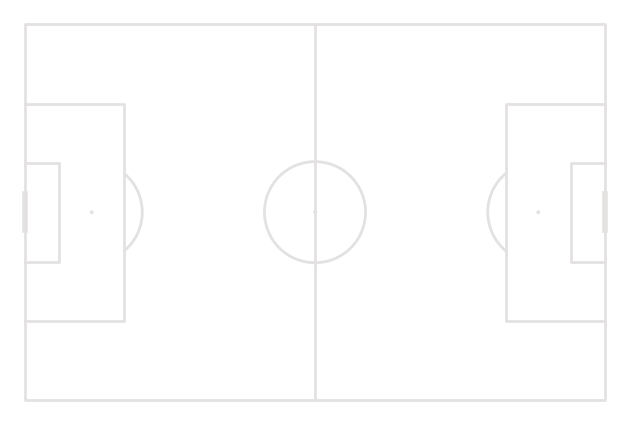

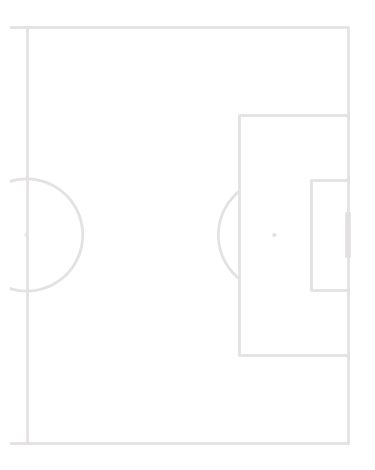

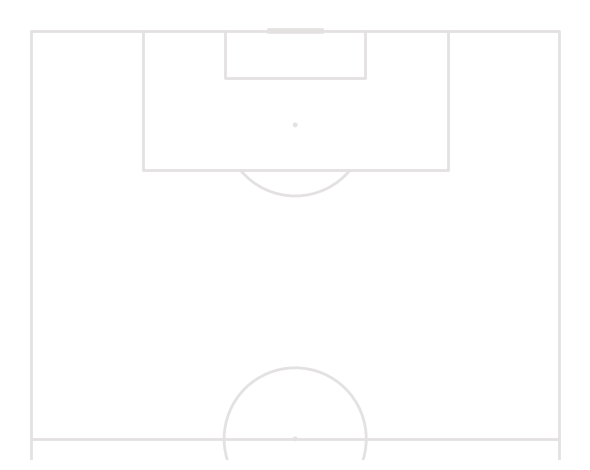

In [11]:
# Llamar a la función plot_pitch para generar diferentes campos de fútbol utilizando las dimensiones del proveedor de datos "Opta"
# ---------------- CAMPO COMPLETO ----------------
plot_pitch(
    pitch_type='opta',        # Dimensiones del campo Opta
    line_color='#E4E1E1',   # Color de las líneas del campo
    outpath='../assets/img',     # Carpeta donde se guardará la imagen 
    filename='picth'          # Nombre base del archivo (se añadirá automáticamente un sufijo)
)

# ---------------- MEDIO CAMPO (LADO IZQUIERDO) ----------------
plot_pitch(
    pitch_type='opta',        # Dimensiones del campo Opta
    half='L',                 # Dibujar solo medio campo (lado izquierdo)
    line_color='#E4E1E1',   # Color de las líneas del campo
    outpath='../assets/img',     # Carpeta donde se guardará la imagen
    filename='picth'          # Nombre base del archivo (se añadirá automáticamente un sufijo)
)


# ---------------- CAMPO VERTICAL ----------------
plot_pitch(
    pitch_type='opta',        # Dimensiones del campo Opta
    vertical=True,            # Dibujar el campo en orientación vertical
    line_color='#E4E1E1',   # Color de las líneas del campo
    outpath='../assets/img',     # Carpeta donde se guardará la imagen
    filename='picth'          # Nombre base del archivo (se añadirá automáticamente un sufijo)
)

<br>

## 3. Creando la identidad del proyecto

En esta sección se describe el proceso de **tratamiento de imágenes** necesario para obtener los logos utilizados en la aplicación.

El primer paso consiste en acceder a **Escudoteca**, una página web que proporciona **escudos de equipos de fútbol en formato PNG y sin fondo**, lo que facilita su integración en la interfaz. Además, la plataforma ofrece la posibilidad de **descargar versiones monocromáticas**, lo que resulta especialmente útil para mantener una estética uniforme en la aplicación.

<br>

### Procesamiento de los Escudos

Una vez obtenidos los escudos, se realiza su **procesamiento mediante Python** para adaptar su visualización en la aplicación.

La función desarrollada permite **convertir los píxeles oscuros a blanco**, manteniendo el **canal de transparencia (alpha)**. Para ello, se recorren las imágenes en formato **PNG**, se transforman en arrays y se aplica un **umbral (threshold)** que identifica los píxeles oscuros.

Estos píxeles son reemplazados por blanco (**RGB = 255, 255, 255**), mientras que la transparencia se conserva intacta. Finalmente, las imágenes procesadas se guardan en una carpeta de salida, obteniendo **escudos homogéneos y optimizados para fondos oscuros**.

In [ ]:
# Función para convertir los escudos con fondo oscuro a blanco, manteniendo la transparencia
def convert_shields_white(input_folder = None, output_folder = None, threshold = None):
     
    # Crear la carpeta de salida si no existe, para guardar los archivos modificados
    os.makedirs(output_folder, exist_ok=True)

    # Recorrer todos los archivos en la carpeta de entrada
    for filename in os.listdir(input_folder):
        
        # Procesar solo archivos PNG
        if filename.lower().endswith(".png"):
            
            # Construir rutas completas de entrada y salida
            input_path = os.path.join(input_folder, filename)
            output_path = os.path.join(output_folder, filename)

            # Abrir la imagen y convertirla a formato RGBA (Red, Green, Blue, Alpha)
            img = Image.open(input_path).convert("RGBA")
            
            # Convertir la imagen a un array de numpy para manipulación de píxeles
            data = np.array(img)

            # Separar los canales de color y el canal alpha (transparencia)
            r, g, b, a = data.T

            # Crear una máscara donde los píxeles sean "oscuros" según el umbral
            mask = (r < threshold) & (g < threshold) & (b < threshold)

            # Cambiar los píxeles oscuros a blanco, manteniendo el canal alpha (transparencia)
            data[..., :-1][mask.T] = [255, 255, 255]

            # Guardar la imagen modificada en la carpeta de salida
            Image.fromarray(data).save(output_path)

    # Mensaje de confirmación al finalizar el proceso
    print(f"✅ Escudos convertidos y guardados en: {output_folder}")

In [ ]:
# Llamar a la función para convertir los escudos con fondo oscuro a blanco
convert_shields_white(
    input_folder = "shields/monocromaticos", 
    output_folder = "shields", 
    threshold = 50
)

✅ Escudos convertidos y guardados en: shields


Tras el procesado de escudos, se procede a **obtener el nombre de los equipos** a partir de los datos disponibles, con el objetivo de **homogeneizar la denominación de las imágenes**.

Este paso es fundamental debido a la posible existencia de **inconsistencias en la nomenclatura** (diferencias de idioma, abreviaturas o variaciones en la escritura), lo que puede dificultar la correcta integración entre datos y recursos visuales.

Por ello, se define un **criterio único de nombrado** que permita **alinear los nombres de los equipos con sus respectivos escudos**, garantizando así la **coherencia y fiabilidad del análisis posterior**.

<br>

#### Nombres de los equipos

In [ ]:
# Función para identificar los nombres de los equipos de "La Liga" en todas las tablas de una base de datos
def identify_teamsName(db_path = None):
    
    try:
        # Conectar a la base de datos SQLite especificada por db_path
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()

        # Obtener los nombres de todas las tablas de la base de datos
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tablas = cursor.fetchall()

        # Si no hay tablas, mostrar mensaje y salir
        if not tablas:
            print("❌ No hay tablas en la base de datos")
            return

        # Mostrar las tablas encontradas
        print(f"✅ Tablas encontradas: {[t[0] for t in tablas]}\n")

        # Iterar sobre cada tabla de la base de datos
        for (tabla,) in tablas:
            print(f"📊 Tabla: {tabla}")
            
            # Leer toda la tabla en un DataFrame de pandas
            df = pd.read_sql_query(f"SELECT * FROM {tabla}", conn)
            
            # Filtrar filas donde la columna 'stats_Comp' es "La Liga" y obtener nombres únicos de equipos
            list_of_teams = df[df["stats_Comp"] == "La Liga"]["stats_Squad"].unique().tolist()
            print(f"Equipos de La Liga: {list_of_teams}")

        # Cerrar la conexión a la base de datos
        conn.close()

    except Exception as e:
        # Captura cualquier error que ocurra y lo imprime
        print(f"❌ Error: {e}")
        
    return list_of_teams

In [ ]:
# Llamar a la función para obtener el nombre de los Equipos de La Liga
list_teamsName = identify_teamsName(
    db_path = "../TFM app/data/players_stats.db"
)

✅ Tablas encontradas: ['stats_players_fbref']

📊 Tabla: stats_players_fbref
Equipos de La Liga: ['Valencia', 'Getafe', 'Alavés', 'Betis', 'Athletic Club', 'Sevilla', 'Espanyol', 'Real Madrid', 'Real Sociedad', 'Villarreal', 'Valladolid', 'Celta Vigo', 'Girona', 'Leganés', 'Atlético Madrid', 'Barcelona', 'Osasuna', 'Mallorca', 'Las Palmas', 'Rayo Vallecano', 'Girona, Villarreal', 'Alavés, Getafe', 'Osasuna, Valladolid', 'Betis, Celta Vigo', 'Celta Vigo, Valladolid', 'Getafe, Villarreal', 'Betis, Getafe', 'Alavés, Valencia', 'Alavés, Villarreal', 'Real Sociedad, Valencia', 'Espanyol, Real Sociedad']


<br>

#### Homogeneización de los Escudos

In [ ]:
# Función para actualizar el nombre de los escudos con el nombre de los equipos encontrados
def update_name_shields(list_teamsName = None, folder_shields = None, threshold = None):
    
    # Función auxiliar para normalizar textos
    def normalizar(texto):
        return ''.join(
            
            # Descompone caracteres acentuados
            c for c in unicodedata.normalize('NFD', texto) 
            
            # Elimina marcas diacríticas (acentos)
            if unicodedata.category(c) != 'Mn'
        
        # Convierte a minúsculas y elimina espacios al inicio/final
        ).lower().strip()                                   
        
    # Función auxiliar para limpiar la lista de equipos
    def limpiar_equipos(lista_equipos):
        
        # Crear una lista vacía que almacenará los nombres de equipos ya procesados
        equipos_limpios = []
        
        # Iterar sobre cada elemento de la lista original de equipos
        for item in lista_equipos:
        
            # Separar posibles nombres múltiples en un solo string
            partes = item.split(",")            
        
            # Iterar sobre cada parte separada
            for p in partes:
        
                # Eliminar espacios al inicio y final, y agregar a la lista limpia
                equipos_limpios.append(p.strip())  
        
        # Eliminar duplicados convirtiendo la lista en un conjunto y luego de nuevo a lista
        return list(set(equipos_limpios))  

    print("🚀 INICIANDO PROCESO DE RENOMBRADO...\n")

    try:
        # Validar que la carpeta de escudos exista
        if not os.path.exists(folder_shields):
            print("❌ La carpeta no existe")
            return

        # Limpiar y preparar lista de equipos únicos
        equipos_limpios = limpiar_equipos(list_teamsName)

        if not equipos_limpios:
            print("❌ No hay equipos para procesar")
            return

        # Listar archivos PNG dentro de la carpeta
        archivos = [f for f in os.listdir(folder_shields) if f.lower().endswith(".png")]

        if not archivos:
            print("❌ No hay archivos PNG en la carpeta")
            return
        
        # Crear diccionario de archivos normalizados sin extensión
        archivos_norm = {
            normalizar(os.path.splitext(f)[0]): f  # Quitamos '.png' antes de normalizar
            for f in archivos
        }

        # Contadores para el resumen final
        encontrados = 0
        no_encontrados = []
        
        # Bucle principal de renombrado con dos intentos
        for intento, th in enumerate([threshold, threshold - 10], start=1):

            # Selecciona los equipos a procesar
            equipos_a_procesar = no_encontrados[:] if intento > 1 else equipos_limpios

            # Actualizar lista de archivos PNG que aún existen en la carpeta
            archivos_existentes = [f for f in os.listdir(folder_shields) if f.lower().endswith(".png")]

            # Normalizar los nombres de los archivos existentes
            archivos_norm = {normalizar(os.path.splitext(f)[0]): f for f in archivos_existentes}

            # Iterar sobre cada equipo a procesar en este intento
            for equipo in equipos_a_procesar:
                
                try:
                    # Normalizar nombre del equipo 
                    equipo_norm = normalizar(equipo)

                    # Buscar el archivo más parecido usando fuzzy matching
                    match_norm, score, _ = process.extractOne(equipo_norm, archivos_norm.keys())

                    # Obtener el nombre original del archivo correspondiente al match
                    archivo_original = archivos_norm[match_norm]

                    # Construir rutas completas de archivo original y archivo de destino
                    old_path = os.path.join(folder_shields, archivo_original)
                    new_name = f"{equipo}.png"                  # Nombre final del archivo
                    new_path = os.path.join(folder_shields, new_name)

                    # Mostrar información en consola
                    print(f"\n🔎 Equipo: {equipo}")
                    print(f"   → Match: {archivo_original}")
                    print(f"   → Similitud: {score:.2f}%")

                    # Si la similitud supera el threshold para este intento
                    if score >= th:
                        
                        # Verificar que el archivo original aún exista
                        if os.path.exists(old_path):
                            
                            # Renombrar (reemplaza si ya existe)
                            os.replace(old_path, new_path)

                            # Mostrar mensaje según sea primer o segundo intento
                            print(f"   ✅ {'SEGUNDO INTENTO ' if intento>1 else ''}RENOMBRADO → {new_name}")

                            # Quitar el equipo de la lista de no renombrados
                            no_encontrados.remove(equipo)

                            # Incrementar contador de encontrados
                            encontrados += 1
                        else:
                            # Si el archivo original ya no está en la carpeta
                            print(f"   ❌ Archivo original no encontrado: {archivo_original}")

                    else:
                        # Si la similitud es baja, no se renombra
                        if intento == 1:
                            no_encontrados.append(equipo)
                        print("   ❌ Similitud baja, no se renombra")

                except Exception as e:
                    # Captura errores específicos para cada equipo
                    print(f"   ❌ Error con equipo '{equipo}': {e}")

                    # En el primer intento, aseguramos que los equipos con error queden en no_encontrados
                    if intento == 1 and equipo not in no_encontrados:
                        no_encontrados.append(equipo)

        # Resumen final del proceso
        print("\n" + "="*50)
        print("📊 RESUMEN FINAL")
        print(f"Equipos únicos procesados: {len(equipos_limpios)}")
        print(f"Renombrados correctamente: {encontrados}")
        print(f"No renombrados / errores: {len(no_encontrados)} → {no_encontrados}")
        print("="*50)

    except Exception as e:
        # Captura cualquier error general del proceso
        print(f"❌ Error general: {e}")

In [ ]:
# Llamar a la función para actualizar el nombre de los escudos con el nombre de los equipos encontrados
update_name_shields(
    list_teamsName = list_teamsName, 
    folder_shields = "shields", 
    threshold = 85
)

🚀 INICIANDO PROCESO DE RENOMBRADO...


🔎 Equipo: Atlético Madrid
   → Match: athletic.png
   → Similitud: 84.00%
   ❌ Similitud baja, no se renombra

🔎 Equipo: Villarreal
   → Match: villarreal.png
   → Similitud: 100.00%
   ✅ RENOMBRADO → Villarreal.png
   ❌ Error con equipo 'Villarreal': list.remove(x): x not in list

🔎 Equipo: Espanyol
   → Match: espanyol.png
   → Similitud: 100.00%
   ✅ RENOMBRADO → Espanyol.png
   ❌ Error con equipo 'Espanyol': list.remove(x): x not in list

🔎 Equipo: Betis
   → Match: betis.png
   → Similitud: 100.00%
   ✅ RENOMBRADO → Betis.png
   ❌ Error con equipo 'Betis': list.remove(x): x not in list

🔎 Equipo: Leganés
   → Match: leganes.png
   → Similitud: 100.00%
   ✅ RENOMBRADO → Leganés.png
   ❌ Error con equipo 'Leganés': list.remove(x): x not in list

🔎 Equipo: Valladolid
   → Match: valladolid.png
   → Similitud: 100.00%
   ✅ RENOMBRADO → Valladolid.png
   ❌ Error con equipo 'Valladolid': list.remove(x): x not in list

🔎 Equipo: Rayo Vallecano
   → 

<br>

### Creación de la identidad visual

Tras completar el procesamiento de los escudos y la homogeneización de los nombres de los equipos, se avanza hacia la construcción de la **identidad visual del proyecto**, concretamente de los **logotipos utilizados en la aplicación**.

Para ello, se han desarrollado dos funciones en Python que permiten generar distintos tipos de logos de forma automatizada:

- La primera función permite crear un **logo vertical**, en el que se combina el **escudo del equipo con su nombre**, generando una composición estructurada y centrada. El proceso incluye la **carga y redimensionado del escudo**, su ajuste en un lienzo transparente y la incorporación de textos personalizados en distintas jerarquías, utilizando fuentes y colores definidos dinámicamente. El resultado es un logo vertical listo para su uso en la interfaz.

- La segunda función genera un **logo simplificado**, basado únicamente en texto. En este caso, se crea un **lienzo transparente** donde se posicionan de forma centrada el nombre principal y secundario del equipo, ajustando automáticamente su alineación horizontal y vertical para mantener una composición equilibrada.

Ambas funciones permiten **automatizar la generación de la identidad visual de los equipos**, garantizando una **estética coherente, escalable y consistente** en toda la aplicación.

In [ ]:
# Función para crear el logo vertical con la imagen del escudo del equipo
def create_logo_vertical(path_shield = None, color_hex = None, start_text = None, end_text = None, size_shield = None, outpath = None, scale_vertical = 1.2):
    
    # Cargar escudo con transparencia
    escudo = Image.open(path_shield).convert("RGBA")

    # Redimensionar escudo
    factor = size_shield / escudo.height
    new_w = int(escudo.width * factor)
    new_h = int(escudo.height * factor)
    escudo_v = escudo.resize((new_w, new_h), Image.Resampling.LANCZOS)

    # Escalar extra para vertical
    new_w_v = int(new_w * scale_vertical)
    new_h_v = int(new_h * scale_vertical)
    escudo_v = escudo_v.resize((new_w_v, new_h_v), Image.Resampling.LANCZOS)

    # Crear lienzo vertical dinámico
    lienzo_v_ancho = max(new_w_v + 40, 400)
    lienzo_v_alto = new_h_v + 150
    lienzo_v = Image.new("RGBA", (lienzo_v_ancho, lienzo_v_alto), (255, 255, 255, 0))
    draw_v = ImageDraw.Draw(lienzo_v)

    # Pegar escudo centrado arriba
    pos_x_escudo_v = (lienzo_v_ancho - new_w_v) // 2
    lienzo_v.paste(escudo_v, (pos_x_escudo_v, 0), escudo_v)

    # Cargar fuentes
    try:
        f_grande = ImageFont.truetype("arialbd.ttf", 53)
        f_pequena = ImageFont.truetype("arial.ttf", 28)
    except:
        f_grande = ImageFont.load_default()
        f_pequena = ImageFont.load_default()

    # Textos centrados debajo del escudo (puedes ajustar distancias si quieres)
    draw_v.text((lienzo_v_ancho // 2, new_h_v - 15), start_text, font=f_grande, fill=color_hex, anchor="ma")
    draw_v.text((lienzo_v_ancho // 2, new_h_v + 45), end_text, font=f_pequena, fill=color_hex, anchor="ma")

    # Guardar logo vertical
    lienzo_v.save(outpath, "PNG")
    print(f"✅ Logo vertical generado: {outpath}\n")

In [ ]:
# Carpeta con escudos
folder_shields = Path("shields")  

# Recorrer todos los PNG de la carpeta
for shield_path in folder_shields.glob("*.png"):
    print(shield_path.stem)  
    
    # Nombre del equipo desde el archivo
    team_name = shield_path.stem  
    
    # Normalizar nombre → quitar acentos, pasar a minúscula, reemplazar espacios por "_"
    team_normalized = (
        unicodedata.normalize("NFKD", team_name)
        .encode("ascii", "ignore")
        .decode("ascii")
        .lower()
        .replace(" ", "_")
    )
    
    # Path de salida para el logo
    outpath = folder_shields / f"logos/Logo_{team_normalized}.png"
    
    # Llamar a tu función create_logo
    create_logo_vertical(
        path_shield = shield_path,
        color_hex = "#FFFFFF",
        start_text = "Data Lab",
        end_text = team_name,
        size_shield = 200,
        outpath = str(outpath)
    )

Alavés
✅ Logo vertical generado: shields\logos\Logo_alaves.png

Athletic Club
✅ Logo vertical generado: shields\logos\Logo_athletic_club.png

Atlético Madrid
✅ Logo vertical generado: shields\logos\Logo_atletico_madrid.png

Barcelona
✅ Logo vertical generado: shields\logos\Logo_barcelona.png

Betis
✅ Logo vertical generado: shields\logos\Logo_betis.png

Celta Vigo
✅ Logo vertical generado: shields\logos\Logo_celta_vigo.png

Espanyol
✅ Logo vertical generado: shields\logos\Logo_espanyol.png

Getafe
✅ Logo vertical generado: shields\logos\Logo_getafe.png

Girona
✅ Logo vertical generado: shields\logos\Logo_girona.png

Las Palmas
✅ Logo vertical generado: shields\logos\Logo_las_palmas.png

Leganés
✅ Logo vertical generado: shields\logos\Logo_leganes.png

Mallorca
✅ Logo vertical generado: shields\logos\Logo_mallorca.png

Osasuna
✅ Logo vertical generado: shields\logos\Logo_osasuna.png

Rayo Vallecano
✅ Logo vertical generado: shields\logos\Logo_rayo_vallecano.png

Real Madrid
✅ Logo verti

In [ ]:
#Función para crear un logo dimple
def create_simple_logo(start_text = None, end_text = None, color_hex = None, outpath = None, canvas_size = None):

    # Crear lienzo transparente
    lienzo = Image.new("RGBA", canvas_size, (255, 255, 255, 0))
    draw = ImageDraw.Draw(lienzo)

    # Cargar fuentes
    try:
        f_grande = ImageFont.truetype("arialbd.ttf", 80)  # Texto principal
        f_pequena = ImageFont.truetype("arial.ttf", 30)   # Texto secundario
    except:
        f_grande = ImageFont.load_default()
        f_pequena = ImageFont.load_default()

    # Medir texto usando textbbox
    bbox_start = draw.textbbox((0,0), start_text, font=f_grande)
    w_start = bbox_start[2] - bbox_start[0]
    h_start = bbox_start[3] - bbox_start[1]

    bbox_end = draw.textbbox((0,0), end_text, font=f_pequena)
    w_end = bbox_end[2] - bbox_end[0]
    h_end = bbox_end[3] - bbox_end[1]

    # Calcular posición vertical centrada
    total_height = h_start + 10 + h_end  
    y_start = (canvas_size[1] - total_height) // 2
    y_end = y_start + h_start + 10

    # Texto centrado horizontalmente
    x_start = (canvas_size[0] - w_start) // 2
    x_end = (canvas_size[0] - w_end) // 2

    # Dibujar textos con offset manual
    draw.text((x_start, y_start - 15), start_text, font=f_grande, fill=color_hex)
    draw.text((x_end, y_end + 15), end_text, font=f_pequena, fill=color_hex)

    # Guardar imagen
    os.makedirs(os.path.dirname(outpath), exist_ok=True)
    lienzo.save(outpath, "PNG")
    print(f"✅ Logo creado y guardado en {outpath}")

In [ ]:
# Llamar a la función para crear un logo simple
create_simple_logo(
    start_text = "Data Lab", 
    end_text = "by Marc Marce Blaya",
    color_hex = "#FFFFFF", 
    outpath = "img/Logo_DataLab.png",
    canvas_size = (450, 250)
)

✅ Logo creado y guardado en img/Logo_DataLab.png


<br>

### Generación de marca de agua

Para finalizar el proceso de creación de la identidad visual, se desarrolla una función específica para generar los **logos en formato marca de agua**, que se utilizarán en distintos elementos de la aplicación.

Esta función parte del **escudo del equipo** y permite crear una versión adaptada en la que, opcionalmente, se aplica una **recoloración a negro** para mejorar su visibilidad sobre diferentes fondos. Posteriormente, el escudo se **redimensiona y ajusta en formato vertical**, y se combina con los textos correspondientes dentro de un **lienzo transparente**.

El resultado es un logo optimizado para su uso como **watermark**, manteniendo la **coherencia visual del sistema** de forma discreta.

In [ ]:
# Función para generar los logos que serán utilizados como marcas de agua
def create_watermark_vertical(path_shield = None, color_hex = None, start_text = None, end_text = None, size_shield = None, outpath = None, scale_vertical = 1.2, recolor = True):
    
    # Cargar escudo
    escudo = Image.open(path_shield).convert("RGBA")
    
    # Función auxiliar para recolorear el escudo
    def recolor_shield(img: Image.Image, target_color=(0, 0, 0)):

        data = np.array(img.convert("RGBA"))

        # Mantener alpha
        alpha = data[..., 3]

        # Aplicar color a todos los píxeles visibles
        data[..., 0] = target_color[0]
        data[..., 1] = target_color[1]
        data[..., 2] = target_color[2]

        # Restaurar alpha
        data[..., 3] = alpha

        return Image.fromarray(data)

    # Recolorear a negro si se activa
    if recolor:
        escudo = recolor_shield(
            escudo,
            target_color=(0, 0, 0)
        )

    # Redimensionar escudo
    factor = size_shield / escudo.height
    new_w = int(escudo.width * factor)
    new_h = int(escudo.height * factor)
    escudo_v = escudo.resize((new_w, new_h), Image.Resampling.LANCZOS)

    # Escala vertical extra
    new_w_v = int(new_w * scale_vertical)
    new_h_v = int(new_h * scale_vertical)
    escudo_v = escudo_v.resize((new_w_v, new_h_v), Image.Resampling.LANCZOS)

    # Lienzo
    lienzo_v_ancho = max(new_w_v + 40, 400)
    lienzo_v_alto = new_h_v + 150
    lienzo_v = Image.new("RGBA", (lienzo_v_ancho, lienzo_v_alto), (255, 255, 255, 0))
    draw_v = ImageDraw.Draw(lienzo_v)

    # Pegar escudo centrado
    pos_x = (lienzo_v_ancho - new_w_v) // 2
    lienzo_v.paste(escudo_v, (pos_x, 0), escudo_v)

    # Fuentes
    try:
        f_grande = ImageFont.truetype("arialbd.ttf", 53)
        f_pequena = ImageFont.truetype("arial.ttf", 28)
    except:
        f_grande = ImageFont.load_default()
        f_pequena = ImageFont.load_default()

    # Textos
    draw_v.text((lienzo_v_ancho // 2, new_h_v - 15), start_text, font=f_grande, fill=color_hex, anchor="ma")
    draw_v.text((lienzo_v_ancho // 2, new_h_v + 45), end_text, font=f_pequena, fill=color_hex, anchor="ma")

    # Guardar
    lienzo_v.save(outpath, "PNG")

    return outpath

In [ ]:
# Carpeta con escudos
folder_shields = Path("shields")  

# Recorrer todos los PNG de la carpeta
for shield_path in folder_shields.glob("*.png"):
    print(shield_path.stem)  
    
    # Nombre del equipo desde el archivo
    team_name = shield_path.stem  
    
    # Normalizar nombre → quitar acentos, pasar a minúscula, reemplazar espacios por "_"
    team_normalized = (
        unicodedata.normalize("NFKD", team_name)
        .encode("ascii", "ignore")
        .decode("ascii")
        .lower()
        .replace(" ", "_")
    )
    
    # Path de salida para el logo
    outpath = folder_shields / f"watermark/Logo_{team_normalized}.png"
    
    # Llamar a tu función create_logo
    create_watermark_vertical(
        path_shield = shield_path,
        color_hex = "#000000",
        start_text = "Data Lab",
        end_text = team_name,
        size_shield = 200,
        outpath = str(outpath),
        recolor = True
    )

Alavés
Athletic Club
Atlético Madrid
Barcelona
Betis
Celta Vigo
Espanyol
Getafe
Girona
Las Palmas
Leganés
Mallorca
Osasuna
Rayo Vallecano
Real Madrid
Real Sociedad
Sevilla
Valencia
Valladolid
Villarreal


<br>

## 4. Estructura de Directorios 

```python
TFM_ZIP/
│
├── app.py
│   # Archivo principal ejecutado por Streamlit; gestiona la navegación entre páginas de la aplicación.
│
├── app_pages/             
│   # Contiene las distintas páginas de la aplicación, cada una enfocada en una funcionalidad específica.
│   │
│   ├── page_home.py           # Página de bienvenida y presentación de la aplicación.
│   ├── page_admin.py          # Gestión de usuarios y roles; permite al administrador controlar accesos y permisos.
│   ├── page_lineup.py         # Generación de alineaciones (lineups).
│   ├── page_list.py           # Creación, gestión y visualización de listas de jugadores.
│   ├── page_newleague.py      # Sugerencias de nuevas ligas que pueden ser importadas al sistema.
│   ├── page_message.py        # Gestión de mensajes, comentarios o feedback de usuarios.
│   ├── page_overview.py       # Exploración, filtrado y visualización general de los datos de jugadores.
│   ├── page_radar.py          # Generación de gráficos tipo radar para comparar estadísticas entre jugadores.
│   └── page_rk.py             # Generación de rankings de jugadores según diferentes métricas.
│   
├── assets/                
│   # Recursos estáticos utilizados en la aplicación (imágenes, tipografías y elementos gráficos).
│   │
│   ├── fonts/                 
│   │   # Tipografías personalizadas utilizadas en la interfaz.
│   │   │   
│   │   ├── DejaVuSans-Bold.ttf
│   │   └── DejaVuSans.ttf
│   │
│   ├── img/                
│   │   # Imágenes generales utilizadas en la aplicación (logos, iconos, gráficos, etc.).
│   │   │   
│   │   ├── Logo_DataLab.png            # Logo principal de la aplicación.
│   │   ├── Freepick...png              # Recursos gráficos obtenidos de Freepik para distintas páginas.
│   │   └── pitch...png                 # Representaciones de campo generadas con mplsoccer.
│   │
│   ├── logo shields/                
│   │   # Logotpios de Escudos de equipos en formato estándar para uso en visualizaciones.
│   │   │   
│   │   └── Logo_Equipos...png
│   │
│   ├── logo watermark/                
│   │   # Logotpios de Escudos en formato marca de agua para uso en visualizaciones.
│   │   │   
│   │   └── Logo_Equipos...png
│   │
│   └── shields/ 
│       # Escudos procesados en versión monocromática (blanca) para uso en visualizaciones.
│       │   
│       └── Equipos...png
│
├── common/                
│   # Módulos y utilidades compartidas entre distintas partes de la aplicación.
│   │
│   ├── config.py              # Define rutas, constantes y configuraciones globales del proyecto.
│   ├── device.py              # Detecta el tipo de dispositivo desde el que se accede a la app.
│   ├── filters.py             # Funciones para filtrar, transformar y encadenar procesamiento de datos.
│   ├── fonts.py               # Funciones para cargar y gestionar fuentes personalizadas.
│   ├── pdf_utils.py           # Utilidades para añadir marcas de agua.
│   └── plots.py               # Funciones encargadas de la generación de visualizaciones.
│
├── controllers/           
│   # Lógica de negocio y control de datos del sistema.
│   │
│   ├── user_controller.py     # Gestión de usuarios, autenticación y control de permisos.
│   ├── logs_export_csv.py     # Registro de filtros aplicados y exportación de datos a CSV.
│   └── db_controller.py       # Interacción con la base de datos (consultas y operaciones).
│ 
├── data/                  
│   # Almacenamiento de datos del proyecto (originales, procesados y generados).
│   │
│   ├── data...xlsx            # Ficheros con datos generados o exportados desde la aplicación.
│   ├── players_stats.db       # Base de datos con estadísticas originales de jugadores (Fbref).
│   └── README_DATA.md         # Documentación del contenido y estructura de los datos.
│
├── models/                
│   # Definición de estructuras de datos y entidades del sistema.
│   │
│   └── user.py                # Modelo de usuario con atributos y métodos asociados.
│
├── notebooks/                
│   # Notebooks de documentación del proyecto.
│   │
│   ├── Anexo - TFM_other_documents.ipynb
│   ├── CRISP-DM.ipynb
│   ├── functions_blaya_fbref.py
│   └── create_logo.py
│
├── .streamlit/            
│   # Configuración específica de Streamlit para la aplicación.
│   │
│   └── config.toml            # Configuración de tema, layout y opciones visuales.
│
├── .env                   
│   # Variables de entorno con información sensible (credenciales, claves, etc.).
│
├── requirements.txt       
│   # Dependencias necesarias para ejecutar el proyecto.
│
├── README.md              
│   # Documentación general del proyecto: instalación, uso y descripción global.
```

<br>

## 5. Del PC a Streamlit

<p style="font-size: 18px; margin-top: 20px; font-weight: bold;">
    Paso 1️⃣ Crear un nuevo repositorio en GitHub
</p>

<p style="margin: 20px 0 0 20px;">
    Entra a GitHub y haz clic en:
</p>

```bash 
New repository
```

<p style="margin: 25px 0 0 20px; line-height: 2;">
    Ponle un nombre, por ejemplo: <strong>TFM_ZIP</strong>.<br>
    Deja <strong>Public</strong> o <strong>Private</strong> según quieras.<br>
    No marques <strong>Initialize with README</strong> (si ya tienes uno local).<br>
    Por acabar selecciona:
</p>

```bash 
Create repository
```
<p style="margin: 25px 0 0 20px;">
    Al final tendrás algo como:
</p>

```bash 
https://github.com/Guaje14/TFM_ZIP.git
```

<p style="font-size: 18px; margin-top: 50px; font-weight: bold;">
    Paso 2️⃣ Ir a tu proyecto local en la terminal
</p>

<p style="margin: 20px 0 0 20px;">
    Abre PowerShell o Bash y ve a tu carpeta de proyecto:
</p>

```bash 
cd "C:\Users\marc_\OneDrive\Escritorio\Visual Studio\TFM_app"
```

<p style="margin: 25px 0 0 20px;">
    Asegúrate de que <strong>app.py</strong> y <strong>requirements.txt</strong> estén en la raíz, no dentro de otra carpeta.
</p>

<p style="font-size: 18px; margin-top: 50px; font-weight: bold;">
    Paso 3️⃣ Inicializar Git
</p>

```bash 
git init
```
<p style="margin: 25px 0 0 20px;">
    Esto crea un repositorio local nuevo.
</p>

<p style="font-size: 18px; margin-top: 50px; font-weight: bold;">
    Paso 4️⃣ Conectar con el repositorio remoto
</p>

```bash 
git remote add origin https://github.com/Guaje14/TFM_ZIP.git
```
<p style="margin: 25px 0 0 20px;">
    Esto indica a Git dónde subir los archivos.
</p>

<p style="font-size: 18px; margin-top: 50px; font-weight: bold;">
    Paso 5️⃣ Añadir todos los archivos al staging
</p>

```bash 
git add .
```
<p style="margin: 25px 0 0 20px;">
    Añade todos los archivos de tu proyecto a Git.
</p>

<p style="font-size: 18px; margin-top: 50px; font-weight: bold;">
    Paso 6️⃣ Hacer commit inicial
</p>

```bash 
# 💡 Es importante poner un mensaje descriptivo para identificar fácilmente qué contiene cada commit.
git commit -m "Primer commit: subir estructura completa de la app Streamlit"
```

<p style="font-size: 18px; margin-top: 50px; font-weight: bold;">
    Paso 7️⃣ Subir al repositorio de GitHub
</p>

<p style="margin: 20px 0 0 20px;">
    Si quieres usar <strong>master</strong> como branch principal:
</p>

```bash 
git branch -M master
git push -u origin master
```
<p style="margin: 25px 0 0 20px;">
    Esto subirá todos tus archivos a GitHub con la estructura correcta.
</p>

<p style="font-size: 18px; margin-top: 50px; font-weight: bold;">
    Paso 8️⃣ Comprobar en GitHub
</p>

<p style="margin: 20px 0 0 20px;">
    Tu repo debería verse así:
</p>

```python
TFM_ZIP/  ← raíz
├── app.py
├── requirements.txt
├── .env
├── assets/
├── app_pages/
├── data/
├── models/
├── controllers/
├── common/
├── notebooks/
├── README.md
```

<p style="margin: 25px 0 0 20px;">
    ✅ Todo listo para Streamlit Cloud, sin carpetas extra.
</p>

<p style="margin: 20px 0 0 20px;">
    App en producción: <a href="https://taream8zip-mot7nfwvap4thnkhhlztds.streamlit.app/" target="_blank">https://taream8zip-mot7nfwvap4thnkhhlztds.streamlit.app/</a>
</p>
<p style="margin-top: 25px; font-weight: bold;">
    Paso 9️⃣ Para reflejar cambios posteriores en el repo:
</p>

```bash 
git add .

git commit -m "Actualizar controllers, páginas y logs de descarga CSV"

git push origin master
```